# **Lab 02 - Introduction to Q-learning**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>
</div>

## Part 1: Implementing Q-learning with the FrozenLake-v1 environment

In [ ]:
# import Gymnasium library and alias as gym
import gymnasium as gym
import random

In [ ]:
# ============================================================
# Q-learning agent for Gymnasium FrozenLake-v1
# ------------------------------------------------------------
# This script trains an agent to learn a state-action value table
# Q(s, a) using the Q-learning algorithm and an epsilon-greedy policy.
#
# Environment:
# - FrozenLake-v1 (4x4 by default)
# - is_slippery=False -> deterministic movement (easier learning)
#
# High-level flow:
# 1) Create environment and agent
# 2) Train over many episodes
# 3) Print and export learned Q-table
# 4) Demonstrate the learned policy in text mode and pygame mode
# ============================================================


class QLearningAgent:
    # Agent stores Q-values in a dictionary keyed by (state, action).
    # If a (state, action) pair has never been seen, its Q-value is treated as 0.
    def __init__(self, env, alpha=0.1, gamma=0.9):
        self.env = env
        self.alpha = alpha  # Learning rate: how much to update old Q-values
        self.gamma = gamma  # Discount factor: importance of future rewards
        self.q_table = {}   # Sparse Q-table: {(state, action): q_value}

    def get_q_value(self, state, action):
        return self.q_table.get((state, action), 0.0)

    def update_q_value(self, state, action, reward, next_state):
        best_next_q = max(
        self.get_q_value(next_state, a) for a in range(self.env.action_space.n)
        )

        current_q = self.get_q_value(state, action)

        target_q = reward + self.gamma * best_next_q

        new_q = (1 - self.alpha) * current_q + self.alpha * target_q

        self.q_table[(state, action)] = new_q

    def choose_action(self, state, epsilon=0.1, policy="epsilon_greedy"):
        # Random policy
        if policy == "random":
            return self.env.action_space.sample()

        # epsilon-greedy
        if random.random() < epsilon:
            return self.env.action_space.sample()

        q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
        max_q = max(q_values)

        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return random.choice(best_actions)

    def choose_greedy_action(self, state):
        q_values = [self.get_q_value(state, a) for a in range(self.env.action_space.n)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return random.choice(best_actions)


def export_q_table_to_txt(agent, file_path="q_table_final.txt"):
    """Export all learned Q-values to a CSV-like text file.

    File format:
        State,Action,Q-value
        0,0,0.000000
        ...
    """
    with open(file_path, "w", encoding="utf-8") as f:
        f.write("State,Action,Q-value\n")
        # Sort keys for stable, readable output
        for (state, action) in sorted(agent.q_table.keys()):
            q_val = agent.q_table[(state, action)]
            f.write(f"{state},{action},{q_val:.6f}\n")
    print(f"Q-table exported to: {file_path}")


def show_final_result_text(agent):
    """Run one full evaluation episode in ANSI text mode.

    - Uses a greedy policy (no exploration).
    - Prints board state after each step.
    - Useful for notebook/terminal environments.
    """
    demo_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="ansi")
    state, _ = demo_env.reset()

    print("=== FINAL RUN WITH GREEDY POLICY (TEXT) ===")
    print(demo_env.render())

    done = False
    step = 0
    reward = 0

    while not done:
        # Pick best action according to learned Q-table
        action = agent.choose_greedy_action(state)

        # Interact with environment
        next_state, reward, terminated, truncated, _ = demo_env.step(action)

        # Episode stops if goal/hole reached (terminated) or cutoff (truncated)
        done = terminated or truncated
        step += 1

        # Log progress and render current map
        print(f"Step {step} - Action: {action}, Reward: {reward}")
        print(demo_env.render())

        # Move to next state
        state = next_state

    # Final status
    print("Agent reached the goal!" if reward > 0 else "Agent failed to reach the goal.")
    demo_env.close()


def show_final_result_pygame(agent, delay_seconds=0.5):
    """
    Run one full evaluation episode with GUI rendering ("human" mode).

    Note:
    - Requires a local environment that supports opening windows.
    - In remote/notebook servers without display, this may not work.
    """
    import time

    demo_env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="human")
    state, _ = demo_env.reset()

    print("=== FINAL RUN WITH GREEDY POLICY (PYGAME/HUMAN) ===")
    done = False
    step = 0
    reward = 0

    while not done:
        action = agent.choose_greedy_action(state)
        next_state, reward, terminated, truncated, _ = demo_env.step(action)
        done = terminated or truncated
        step += 1

        print(f"Step {step} - Action: {action}, Reward: {reward}")
        state = next_state

        # Slow down transitions so movement can be observed clearly
        time.sleep(delay_seconds)

    print("Agent reached the goal!" if reward > 0 else "Agent failed to reach the goal.")

    # Keep final frame visible briefly
    time.sleep(1.0)
    demo_env.close()


# ============================================================
# Training routine
# ============================================================

if __name__ == "__main__":
    env = gym.make("FrozenLake-v1", is_slippery=False)
    agent = QLearningAgent(env)

    num_episodes = 1000

    rewards_qlearning = []
    rewards_random = []

    # Main training loop
    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = agent.choose_action(state, epsilon=0.1)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.update_q_value(state, action, reward, next_state)

            state = next_state
            total_reward += reward

        rewards_qlearning.append(total_reward)

    # Random policy
    for _ in range(num_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = env.action_space.sample()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            state = next_state
            total_reward += reward

        rewards_random.append(total_reward)

    # Print learned Q-table entries
    print("Training completed. Q-table:")
    for (state, action) in sorted(agent.q_table.keys()):
        q_val = agent.q_table[(state, action)]
        print(f"State: {state}, Action: {action}, Q-value: {q_val:.2f}")

    # Save Q-table to file for later inspection/use
    export_q_table_to_txt(agent, "q_table_final.txt")

    # Show one text-based demonstration run
    show_final_result_text(agent)

    # Show one GUI-based demonstration run
    show_final_result_pygame(agent, delay_seconds=0.4)

    # Release training environment resources
    env.close()

Training completed. Q-table:
State: 0, Action: 0, Q-value: 0.48
State: 0, Action: 1, Q-value: 0.39
State: 0, Action: 2, Q-value: 0.59
State: 0, Action: 3, Q-value: 0.51
State: 1, Action: 0, Q-value: 0.46
State: 1, Action: 1, Q-value: 0.00
State: 1, Action: 2, Q-value: 0.66
State: 1, Action: 3, Q-value: 0.54
State: 2, Action: 0, Q-value: 0.52
State: 2, Action: 1, Q-value: 0.73
State: 2, Action: 2, Q-value: 0.37
State: 2, Action: 3, Q-value: 0.55
State: 3, Action: 0, Q-value: 0.58
State: 3, Action: 1, Q-value: 0.00
State: 3, Action: 2, Q-value: 0.00
State: 4, Action: 0, Q-value: 0.05
State: 4, Action: 1, Q-value: 0.00
State: 4, Action: 2, Q-value: 0.00
State: 4, Action: 3, Q-value: 0.51
State: 6, Action: 0, Q-value: 0.00
State: 6, Action: 1, Q-value: 0.81
State: 6, Action: 2, Q-value: 0.00
State: 6, Action: 3, Q-value: 0.57
State: 8, Action: 0, Q-value: 0.00
State: 8, Action: 1, Q-value: 0.00
State: 8, Action: 2, Q-value: 0.00
State: 8, Action: 3, Q-value: 0.09
State: 9, Action: 0, Q-val

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def moving_average(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.plot(moving_average(rewards_qlearning), label="Q-learning (smoothed)")
plt.plot(moving_average(rewards_random), label="Random (smoothed)")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-learning vs Random Policy")
plt.legend()
plt.show()

## Part 2: Q-learning with Custom Environment "VacuumCleaner"

In [ ]:
# Build a simple custom Gymnasium environment named "VacuumCleaner-v0".
# The environment simulates a vacuum robot operating in an m x n room. The robot can
# move up, down, left, and right and automatically vacuums the cell it occupies.
# The objective is to clean all dust particles in the room. There is a single obstacle
# located at a specified cell (i, j) that the robot must avoid. Entering the obstacle
# cell yields a large negative reward and terminates the episode.
# The robot receives a positive reward when it vacuums a dirty cell. If the robot
# attempts to vacuum an already clean cell, that action receives a reduced reward
# (e.g., penalized or halved). When all dust has been cleaned, the agent receives
# a large positive bonus reward and the episode terminates.
# Action space: Discrete(4) -> {0: up, 1: down, 2: left, 3: right}
# Observation space: Dict with 'position' (x, y) and 'dust' grid (m x n binary)

import numpy as np
import os
import time
from IPython.display import clear_output

class VacuumCleanerEnv(gym.Env):
    def __init__(self, m=5, n=5, obstacle=(2, 2)):
        super(VacuumCleanerEnv, self).__init__()
        self.m = m
        self.n = n
        self.obstacle = tuple(obstacle)

        # Action space: 0=up, 1=down, 2=left, 3=right
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE

        # Observation space: position and dust grid
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.observation_space = gym.spaces.Dict({
            'position': 
            'dust': 
        })

        self.reset()

    def reset(self, *, seed=None, options=None):
        # initialize position and dust
        # Start the robot at the top-left corner (row 0, column 0)
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.position = 

        # Initialize dust grid: 1 indicates dirty, 0 indicates clean.
        # Shape is (m, n) corresponding to the room dimensions.
        # Use NUMPY to define.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE
        self.dust_grid = 

        # Ensure the obstacle cell contains no dust (robot cannot clean there).
        # This also prevents rewarding the agent for occupying the obstacle.
        self.dust_grid[self.obstacle] = 0  # obstacle cell has no dust
        self.total_reward = 0.0
        self.truncated = False
        self.terminated = False
        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, {}

    def step(self, action):
        # compute candidate new position
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        if action == 0:   # Up
            candidate = 
        elif action == 1: # Down
            candidate = 
        elif action == 2: # Left
            candidate = 
        elif action == 3: # Right
            candidate = 
        else:
            candidate = self.position.copy()

        # boundary check
        if (0 <= candidate[0] < self.m) and (0 <= candidate[1] < self.n):
            # obstacle check
            if tuple(candidate) == self.obstacle:
                self.position = candidate.copy()
                reward = -10.0
                self.terminated = True
                obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
                self.total_reward += reward
                return obs, reward, True, False, {}
            else:
                self.position = candidate.copy()
        # else: stay in place

        # If the robot is on a dirty cell, give a positive reward (1.0) and mark it clean.
        # If the cell is already clean, apply a small penalty (-0.5) to discourage redundant cleaning.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        # HERE

        
        self.total_reward += reward

        # check if all cleaned
        if np.sum(self.dust_grid) == 0:
            reward += 10.0
            self.terminated = True

        obs = {'position': self.position.copy(), 'dust': self.dust_grid.copy()}
        return obs, reward, bool(self.terminated), bool(self.truncated), {}

    def render(self, mode='human'):
        # In Jupyter notebooks, use IPython.display.clear_output to clear the cell output.
        try:
            clear_output(wait=True)
        except Exception:
            # Fallback for terminal execution
            os.system('cls' if os.name == 'nt' else 'clear')

        # Build display grid with symbols:
        # '#' obstacle, '.' dirty, ' ' clean, 'R' robot, 'X' robot on obstacle
        display = np.full((self.m, self.n), ' ', dtype='<U1')
        for i in range(self.m):
            for j in range(self.n):
                if (i, j) == self.obstacle:
                    display[i, j] = '#'
                elif self.dust_grid[i, j] == 1:
                    display[i, j] = '.'
                else:
                    display[i, j] = ' '

        x, y = int(self.position[0]), int(self.position[1])
        if (x, y) == self.obstacle:
            display[x, y] = 'X'
        else:
            display[x, y] = 'R'

        for row in display:
            print(''.join(row))
        print(f"Total reward: {self.total_reward}")
        time.sleep(0.15)

In [ ]:
def robot_policy(option="random", env=None):
     """
     A simple policy function that selects an action based on the specified option.
     Currently supports only a random policy.
     """
     if option == "random":
          return env.action_space.sample()  # Randomly select an action from the action space
     

In [ ]:
if __name__ == "__main__":
    env = VacuumCleanerEnv(m=5, n=5, obstacle=(2, 2))
    obs, _ = env.reset()
    env.render()
    terminated = False
    truncated = False

    while not terminated and not truncated:
        action = robot_policy(option="random", env=env)
        obs, reward, terminated, truncated, info = env.step(action)
        env.render()
        print(f"Action: {action}, Reward: {reward}, Terminated: {terminated}")
        if terminated or truncated:
            print("Episode finished with total reward:", env.total_reward)
            break

In [ ]:
def save(...):
    pass

Evaluation and Analysis

## Part 3: Q-learning with Load Balancing Problem

In [7]:
"""
Load Balancing Environment Simulation

This program simulates a load balancing environment where tasks are distributed among multiple servers. 
Each server has a queue with a limited size, and tasks are processed based on their arrival and the server's availability.

Key Components:
1. Task: Represents a task with a specific processing time.
2. Server: Represents a server that processes tasks. Each server has a queue to hold tasks waiting for processing.
3. LoadBalancingEnv: A custom OpenAI Gym environment that simulates the load balancing scenario. 
     The environment allows agents to decide which server to send a task to, aiming to maximize rewards by minimizing 
     dropped tasks and reducing waiting times.

The goal is to design a load balancing strategy that optimally distributes tasks among servers to maximize efficiency.

Classes:
- Task: Represents a task with a specific processing time.
- Server: Represents a server with a queue of limited size.
- LoadBalancingEnv: Custom Gym environment for the load balancing problem.

Usage:
- The environment can be used to train reinforcement learning agents to learn optimal load balancing strategies.
"""

import random
from collections import deque

class Task:
      """A task with a unique id and required processing time (in time steps)."""

      def __init__(self, task_id: int, processing_time: int):
            self.task_id = task_id  # Unique identifier for tracking
            self.processing_time = processing_time  # Number of steps needed to finish


class Server:
      """
      A server with:
      - one currently running task
      - a waiting queue with finite capacity
      """

      def __init__(self, queue_capacity: int):
            self.queue_capacity = queue_capacity  # Max number of tasks waiting in queue
            self.queue = deque()  # FIFO queue of waiting tasks
            self.current_task = None  # Task being processed right now
            self.remaining_time = 0  # Steps left for current_task

      def run_one_step(self):
            """
            Execute one simulation step on this server.

            Returns:
                  completed_task (Task | None): task completed at this step, if any.
            """
            completed_task = None

            # Process one time unit for currently running task
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.current_task is not None:
                  self.remaining_time -= 1

            if self.remaining_time <= 0:
                  completed_task = self.current_task
                  self.current_task = None
            # If server becomes idle, immediately pull next task from queue
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.current_task is None and len(self.queue) > 0:
                  next_task = self.queue.popleft()
                  self.current_task = next_task
                  self.remaining_time = next_task.processing_time
            return completed_task

      def add_task(self, task: Task) -> bool:
            """
            Try to add a task to this server.

            Rules:
            - If server is idle: start processing immediately.
            - Else if queue has room: enqueue task.
            - Else: reject (drop) task.

            Returns:
                  bool: True if accepted, False if dropped.
            """
            # Start immediately if server is free
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if self.current_task is None:
                  self.current_task = task
                  self.remaining_time = task.processing_time
                  return True
            # Otherwise enqueue if capacity allows
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            if len(self.queue) < self.queue_capacity:
                  self.queue.append(task)
                  return True
            # Queue full -> task dropped
            return False

      def queue_length(self) -> int:
            # Current number of waiting tasks (excluding running task)
            return len(self.queue)

In [8]:
import random
class LoadBalancingEnv(gym.Env):
      """
      Custom Gym environment for load balancing.

      Action:
            Choose a server index to receive the new incoming task.

      State:
            - each server's remaining processing time and queue length
            - global time step

      Metrics tracked:
            - total_created_tasks
            - accepted_tasks
            - dropped_tasks
            - completed_tasks
            - drop_rate
      """

      metadata = {"render.modes": ["human"]}

      def __init__(self, n_servers: int = 3, queue_capacity: int = 2, seed: int = None):
            super().__init__()
            self.n_servers = n_servers
            
            self.rng = random.Random(seed)  # Local random generator for reproducibility
            self.queue_capacity = self.rng.randint(0,queue_capacity )
            # Create server pool
            self.servers = [Server(queue_capacity) for _ in range(n_servers)]
            self.time = 0  # Global simulation step
            self.total_reward = 0.0  # Accumulated reward over episode

            # Task tracking
            self.next_task_id = 0
            self.tasks_created = {}     # task_id -> Task
            self.tasks_completed = set()  # IDs of completed tasks
            self.tasks_dropped = set()  # IDs of dropped tasks
            self.tasks_accepted = set()  # IDs of accepted tasks

            # RL spaces
            # Define action space with n_servers 
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.action_space = gym.spaces.Discrete(self.n_servers)

            # Define observation space as a dict containing server states and global time
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.observation_space = gym.spaces.Dict({
                  "servers": gym.spaces.Tuple(
                        tuple(
                              gym.spaces.Dict({
                                    "remaining_time": gym.spaces.Box(low=0, high=10, shape=(), dtype=float),
                                    "queue_length": gym.spaces.Discrete(self.queue_capacity + 1),
                              })
                              for _ in range(self.n_servers)
                        )
                  ),
                  "time": gym.spaces.Box(low=0, high=10000, shape=(), dtype=float),
            })


      def _new_task(self) -> Task:
            """Create one new incoming task with random processing time [1, 5]."""
            # Create a new task with a unique ID and random processing time between 1 and 5
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            t_time = self.rng.choices([1, 2, 3, 4, 5], weights=[5, 5, 10, 35, 45], k=1)[0]

            t = Task(
            task_id=self.next_task_id,
            processing_time=t_time
            )
            
            self.tasks_created[t.task_id] = t
            self.next_task_id += 1
            return t

      def reset(self, *, seed=None, options=None):
            """Reset environment state and all tracking metrics."""
            # Optional reseed to make episode deterministic from this point
            if seed is not None:
                  self.rng.seed(seed)

            # Reinitialize server states, time, and rewards
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.servers = [Server(self.queue_capacity) for _ in range(self.n_servers)]
            self.time = 0
            self.total_reward = 0.0
            self.next_task_id = 0
            # Clear all task statistics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            self.tasks_created = {}
            self.tasks_completed = set()
            self.tasks_dropped = set()
            self.tasks_accepted = set()

            # Gymnasium-style reset return: (observation, info)
            return self._get_observation(), {}

      def step(self, action: int):
            """
            Run one simulation step:
            1) Advance all servers by one time step.
            2) Generate one new task.
            3) Route task to selected server.
            4) Compute reward and return transition tuple.
            """
            reward = 0.0

            # 1) Process running tasks on each server
            # For each server, call run_one_step() to advance processing. If a task completes, add to completed set and give a positive reward (+2.0)
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for server in self.servers:
                  completed = server.run_one_step()
                  if completed is not None:
                        self.tasks_completed.add(completed.task_id)
                        reward += 2.0

            # 2) Generate one new incoming task
            new_task = self._new_task()

            # 3) Route task based on action (selected server index)
            # Try to add the new task to the selected server. 
            # If accepted, add to accepted set and give a small reward (+0.5). 
            # If dropped, add to dropped set and give a strong penalty (-5.0).
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            server = self.servers[action]

            accepted = server.add_task(new_task)

            if accepted:
                  self.tasks_accepted.add(new_task.task_id)
                  reward += 0.5
            else:
                  self.tasks_dropped.add(new_task.task_id)
                  reward -= 5.0
      
            # 4) Add congestion penalty proportional to queue sizes
            # To encourage the agent to balance load and avoid long queues, subtract a small penalty (e.g., -0.5) for each task waiting in any server's queue.
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            for server in self.servers:
                  reward -= 0.5 * server.queue_length()

            # Update global counters
            self.total_reward += reward
            self.time += 1

            # This environment currently never ends by itself
            terminated = False
            truncated = False
            info = self._get_info()

            return self._get_observation(), reward, terminated, truncated, info

      def _get_observation(self):
            """Build observation dict from current system state."""
            # As a hint to design your observation, we provide the following structure:
            return {
                  "servers": tuple(
                         {
                               "remaining_time": float(server.remaining_time),
                               "queue_length": server.queue_length(),
                         }
                         for server in self.servers
                  ),
                  "time": float(self.time),
            }

      def _get_info(self):
            """Return useful metrics for logging/evaluation."""
            # Compute metrics based on requirements on your lab assignment. Here are some examples:
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            total_created = len(self.tasks_created)
            dropped = len(self.tasks_dropped)
            completed = len(self.tasks_completed)
            accepted = len(self.tasks_accepted)

            # Safe division to avoid divide-by-zero at the beginning
            # Calculate some key performance metrics
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            drop_rate = dropped / total_created if total_created > 0 else 0.0
            #...

            return {
                  # Some example info fields: time, dropped tasks, dop_rate, etc.
                  "time": self.time,
                  "total_created": total_created,
                  "accepted": accepted,
                  "completed": completed,
                  "dropped": dropped,
                  "drop_rate": drop_rate,
                  "total_reward": self.total_reward
            }

In [9]:
# Hàm Qlearn
def obs_to_state(obs):
    # Loại bỏ biến "time" để tránh bùng nổ trạng thái
    # Ép remaining_time về int để gom nhóm các trạng thái tương đồng
    return tuple(
        (int(s["remaining_time"]), s["queue_length"])
        for s in obs["servers"]
    )

def q_update(q_table, state, action, reward, next_state, alpha=0.1, gamma=0.9, n_actions=3):
    # Khởi tạo state nếu chưa có
    if state not in q_table:
        q_table[state] = [0.0] * n_actions

    if next_state not in q_table:
        q_table[next_state] = [0.0] * n_actions

    # Lấy giá trị Q tốt nhất của trạng thái tiếp theo
    best_next = max(q_table[next_state])

    # Công thức Bellman chuẩn
    q_table[state][action] += alpha * (
        reward + gamma * best_next - q_table[state][action]
    )

In [10]:
def load_balancing_policy(option="random", env=None, q_table=None, state=None, epsilon=0.1):
      """Simple baseline policy."""
      if option == "random":
            # Uniform random server selection
            return env.action_space.sample()
      # Define other policies based on the option string
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE      
      if option == "round_robin":
            action = env.time % env.n_servers
            return action
      if option == "q_learning":
            # epsilon-greedy
            current_epsilon = max(0.1, epsilon * (0.9 ** env.time))
            if random.random() < current_epsilon:
                  return env.action_space.sample()

            if state not in q_table:
                  q_table[state] = [0.0] * env.n_servers

            return q_table[state].index(max(q_table[state]))
   
      raise ValueError(f"Unsupported policy option: {option}")

In [11]:
if __name__ == "__main__":
      # Create environment and reset initial state
      env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=42)
      obs, info = env.reset()

      # Run fixed number of simulation steps with random policy
      for step in range(20): # 20 episodes = 20 steps = 20 seconds of simulated time = 20 tasks created
            action = load_balancing_policy(option="q_learning", env=env,
                              q_table={},
                              state=obs_to_state(obs))
            obs, reward, terminated, truncated, info = env.step(action)
            
            # Print every value you want to track at each step
            # Save metrics to a csv file for later analysis
            ### YOU NEED TO WRITE YOUR CODE BELOW ###
            # HERE
            print(
                  f"Step {step} | "
                  f"Action {action} | "
                  f"Reward {reward:.2f} | "
                  f"Dropped {info['dropped']} | "
                  f"Completed {info['completed']} | "
                  f"DropRate {info['drop_rate']:.2f}"
            )
      # Print summary statistics after simulation ends.
      ### YOU NEED TO WRITE YOUR CODE BELOW ###
      # HERE
      print("\n===== Simulation Summary =====")
      print("Total tasks created:", info["total_created"])
      print("Accepted:", info["accepted"])
      print("Completed:", info["completed"])
      print("Dropped:", info["dropped"])
      print("Drop rate:", info["drop_rate"])
      print("Total reward:", info["total_reward"])

Step 0 | Action 0 | Reward 0.50 | Dropped 0 | Completed 0 | DropRate 0.00
Step 1 | Action 0 | Reward 0.00 | Dropped 0 | Completed 0 | DropRate 0.00
Step 2 | Action 0 | Reward -0.50 | Dropped 0 | Completed 0 | DropRate 0.00
Step 3 | Action 0 | Reward 1.50 | Dropped 0 | Completed 1 | DropRate 0.00
Step 4 | Action 0 | Reward -6.00 | Dropped 1 | Completed 1 | DropRate 0.20
Step 5 | Action 0 | Reward -6.00 | Dropped 2 | Completed 1 | DropRate 0.33
Step 6 | Action 0 | Reward -6.00 | Dropped 3 | Completed 1 | DropRate 0.43
Step 7 | Action 0 | Reward -6.00 | Dropped 4 | Completed 1 | DropRate 0.50
Step 8 | Action 0 | Reward 1.50 | Dropped 4 | Completed 2 | DropRate 0.44
Step 9 | Action 0 | Reward -6.00 | Dropped 5 | Completed 2 | DropRate 0.50
Step 10 | Action 0 | Reward -6.00 | Dropped 6 | Completed 2 | DropRate 0.55
Step 11 | Action 0 | Reward -6.00 | Dropped 7 | Completed 2 | DropRate 0.58
Step 12 | Action 0 | Reward 1.50 | Dropped 7 | Completed 3 | DropRate 0.54
Step 13 | Action 0 | Reward

In [28]:
import csv
import time

def save_metrics(policy="random", episodes=100, steps=100):

      filename = f"metrics_{policy}.csv"
      env = LoadBalancingEnv(n_servers=3, queue_capacity=2, seed=42)
      with open(filename, "w", newline="") as f:

            writer = csv.writer(f)

            writer.writerow([
                  "episode",
                  "total_time",
                  "total_created_tasks",
                  "accepted_tasks",
                  "dropped_tasks",
                  "completed_tasks",
                  "total_reward"
            ])

            q_table = {}

            for ep in range(episodes):

                  

                  obs, _ = env.reset()

                  start = time.time()

                  for step in range(steps):

                        state = obs_to_state(obs)

                        action = load_balancing_policy(
                              option=policy,
                              env=env,
                              q_table=q_table,
                              state=state
                        )

                        next_obs, reward, terminated, truncated, info = env.step(action)

                        next_state = obs_to_state(next_obs)

                        if policy == "q_learning":
                              q_update(
                                    q_table,
                                    state,
                                    action,
                                    reward,
                                    next_state,
                                    n_actions=env.n_servers
                              )

                        obs = next_obs

                  runtime = time.time() - start

                  writer.writerow([
                        ep,
                        runtime,
                        info["total_created"],
                        info["accepted"],
                        info["dropped"],
                        info["completed"],
                        info["total_reward"]
                  ])

      print(f"Saved metrics to {filename}")

In [29]:
save_metrics(policy="round_robin", episodes=100, steps=100)
save_metrics(policy="q_learning", episodes=100, steps=100)

Saved metrics to metrics_round_robin.csv
Saved metrics to metrics_q_learning.csv


In [30]:
#Hàm điền bảng
import csv
import numpy as np

def load_metrics(filename):
    episodes, rewards, drops, completions = [], [], [], []
    try:
        with open(filename, "r") as f:
            reader = csv.DictReader(f)
            for row in reader:
                episodes.append(int(row["episode"]))
                rewards.append(float(row["total_reward"]))
                drops.append(int(row["dropped_tasks"]))
                completions.append(int(row["completed_tasks"]))
    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file {filename}")
        return [0], [0], [0], [0]
    return episodes, rewards, drops, completions

# Load dữ liệu
ep_rr, reward_rr, drop_rr, comp_rr = load_metrics("metrics_round_robin.csv")
ep_q, reward_q, drop_q, comp_q = load_metrics("metrics_q_learning.csv")

# Tính toán các chỉ số trung bình (Average) trên tất cả episodes
metrics = {
    "Average Reward": [np.mean(reward_q), np.mean(reward_rr)],
    "Drop Rate (Avg)": [np.mean(drop_rr), np.mean(drop_q)],
    "Completion Rate (Avg)": [np.mean(comp_q), np.mean(comp_rr)]
}

# In bảng ra Terminal
print(f"{'Metric':<25} | {'Q-learning':<15} | {'Round Robin':<15}")
print("-" * 60)
for key, values in metrics.items():
    print(f"{key:<25} | {values[0]:<15.2f} | {values[1]:<15.2f}")


Metric                    | Q-learning      | Round Robin    
------------------------------------------------------------
Average Reward            | -166.03         | -155.62        
Drop Rate (Avg)           | 21.58           | 24.37          
Completion Rate (Avg)     | 67.88           | 70.31          


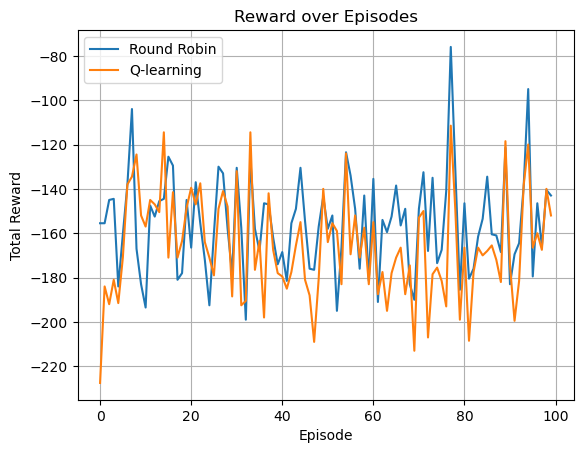

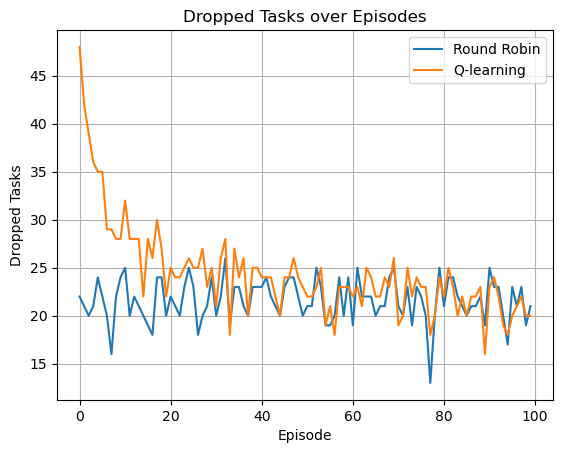

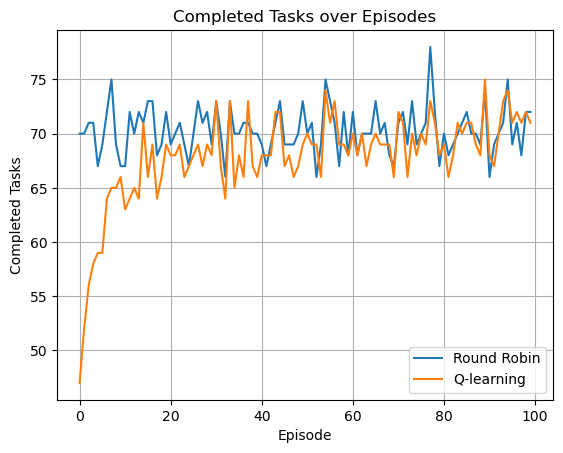

In [31]:
import csv
import matplotlib.pyplot as plt

def load_metrics(filename):

    episodes = []
    rewards = []
    drops = []
    completions = []

    with open(filename, "r") as f:
        reader = csv.DictReader(f)

        for row in reader:
            episodes.append(int(row["episode"]))
            rewards.append(float(row["total_reward"]))
            drops.append(int(row["dropped_tasks"]))
            completions.append(int(row["completed_tasks"]))

    return episodes, rewards, drops, completions


# Load dữ liệu
ep_rr, reward_rr, drop_rr, comp_rr = load_metrics("metrics_round_robin.csv")
ep_q, reward_q, drop_q, comp_q = load_metrics("metrics_q_learning.csv")


# ===== Plot Reward =====
plt.figure()

plt.plot(ep_rr, reward_rr, label="Round Robin")
plt.plot(ep_q, reward_q, label="Q-learning")

plt.title("Reward over Episodes")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid()

plt.show()


# ===== Plot Drop =====
plt.figure()

plt.plot(ep_rr, drop_rr, label="Round Robin")
plt.plot(ep_q, drop_q, label="Q-learning")

plt.title("Dropped Tasks over Episodes")
plt.xlabel("Episode")
plt.ylabel("Dropped Tasks")
plt.legend()
plt.grid()

plt.show()


# ===== Plot Completion =====
plt.figure()

plt.plot(ep_rr, comp_rr, label="Round Robin")
plt.plot(ep_q, comp_q, label="Q-learning")

plt.title("Completed Tasks over Episodes")
plt.xlabel("Episode")
plt.ylabel("Completed Tasks")
plt.legend()
plt.grid()

plt.show()

Evaluation and Analysis

## CONGRATULATIONS TEAM!

Congratulations to the team for completing Lab02 - Introduction to Q-learning.
Keep up the effort in the next sections.

References: https://gymnasium.farama.org/ 

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn
